# <center>Finding Implied Volatility</center>

Plan:
1. Get the risk free rate from Yield Curve.ipynb
2. Pull every other parameter for the black scholes formula
3. Apply Newton Raphson Method to find the implied volatility



# <center>Yield Curve Interpolation</center>

Lets interpolate the risk free interest rate curve with US Treasuries Yield. First, get the data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf
import pandas as pd
from datetime import datetime
import seaborn as sns

In [3]:
def extract_yield_data(file_path):
    # Read the file.
    df = pd.read_excel(file_path)

    # Grab the raw data columns
    raw_tenors = df.iloc[:, 0].astype(str)
    raw_yields = df.iloc[:, 8].astype(float)

    # Tenor mapping to years. 
    tenor_mapping = {
        '1M': 1/12, '6W': 1.5/12, '2M': 2/12, '3M': 3/12, 
        '4M': 4/12, '6M': 6/12, '1Y': 1.0, '2Y': 2.0, 
        '3Y': 3.0, '5Y': 5.0, '7Y': 7.0, '10Y': 10.0, 
        '20Y': 20.0, '30Y': 30.0
    }

    x_maturities = []
    y_yields = []

    # Loop through the rows and match the text
    for i in range(len(raw_tenors)):
        clean_tenor = raw_tenors.iloc[i].strip()
        if clean_tenor in tenor_mapping:
            x_maturities.append(tenor_mapping[clean_tenor])
            y_yields.append(raw_yields.iloc[i])

    return np.array(x_maturities), np.array(y_yields)

By now, we have learnt in class that with Cubic Spline Interpolation:

For any given interval $i$, the polynomial looks like this:$$S_i(x) = a_i + b_i(x - x_i) + c_i(x - x_i)^2 + d_i(x - x_i)^3$$

In [4]:
def calculate_spline_coefficients(x, y):
    # Takes the X (maturities) and Y (yields) arrays and calculates the spline coefficients
    n = len(x) - 1

    a = y[:-1]
    h = np.diff(x)

    # Tridiagonal Matrix A and Vector B
    A = np.zeros((n + 1, n + 1))
    B = np.zeros(n + 1)

    # Natural Boundary Conditions (Condition 3a from your textbook)
    # Forces the second derivative (curvature) at the very ends to be 0
    A[0, 0] = 1.0
    A[n, n] = 1.0

    # Loop through the inner knots to match the derivatives (derivation is in week 9 and 10)
    for i in range(1, n):
        A[i, i-1] = h[i-1]
        A[i, i] = 2 * (h[i-1] + h[i])
        A[i, i+1] = h[i]

        # Calculate the right side of the equation
        B[i] = 3 * (y[i+1] - y[i]) / h[i] - 3 * (y[i] - y[i-1]) / h[i-1]

    # Solve the matrix equation Ac = B to find c
    c_full = np.linalg.solve(A, B)
    c = c_full[:-1]
                                                                                                                                                                                             
    # Solve for 'b' and 'd' using algebraic substitution
    b = np.zeros(n)
    d = np.zeros(n)

    for i in range(n):
        b[i] = (y[i+1] - y[i]) / h[i] - h[i] * (2 * c_full[i] + c_full[i+1]) / 3
        d[i] = (c_full[i+1] - c_full[i]) / (3 * h[i])

    return a, b, c, d
    

Now we got the set of coefficients of a, b, c, d where y_target = 
$$S_i(x) = a_i + b_i(x - x_i) + c_i(x - x_i)^2 + d_i(x - x_i)^3$$

In [5]:
def get_y(x_target, x_nodes, y_nodes, a, b, c, d):
    # Return interpolated y for a given maturity x_target

    # Safety Check: If they ask for a yield outside our data (like 50 years),
    # we just return the flat rate of our very last data point to avoid errors.
    if x_target <= x_nodes[0]:
        return y_nodes[0]
    if x_target >= x_nodes[-1]:
        return y_nodes[-1]

    # 1. Find the correct interval 'i'
    i = np.searchsorted(x_nodes, x_target) - 1

    # 2. Calculate the distance from the start of the interval
    dx = x_target - x_nodes[i]

    # 3. Evaluate the cubic polynomial for this specific interval
    y_target = a[i] + b[i]*(dx) + c[i]*(dx**2) + d[i]*(dx**3)

    return y_target

Additionally, we can graph the curve to help us get a better understanding of the market dynamics.

In [20]:
def graph_spline(x_nodes, y_nodes, a, b, c, d):
    # Plot the spline

    # Generate 500 evenly spaced 'x' points from our first to last maturity
    dense_x = np.linspace(min(x_nodes), max(x_nodes), 5000)

    # get_y() for each point x
    dense_y = []
    for xt in dense_x:
        result = get_y(xt, x_nodes, y_nodes, a, b, c, d)
        dense_y.append(result)

    plt.figure(figsize=(10, 6))

    plt.plot(dense_x, dense_y, label="Natural Cubic Spline")
    plt.plot(x_nodes, y_nodes, 'ro', label="Bloomberg Data Knots", markersize=6)

    plt.title("US Treasury Yield Curve Cubic Spline Interpolation")
    plt.xlabel("Maturity (Years)")
    plt.ylabel("Yield (%)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.show()

Run Everything for the yield curve.

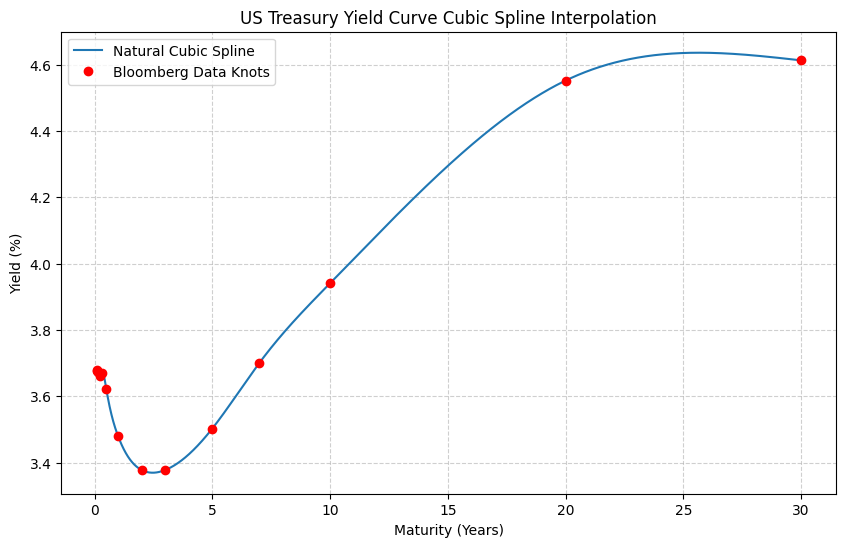

In [21]:
# Extract yield data
x, y = extract_yield_data('US Yield Curve 27022026 YCGT0025.xlsx')

# Calculate spline coefficients
a, b, c, d = calculate_spline_coefficients(x, y)

# Graph the spline
graph_spline(x, y, a, b, c, d)

What if we use Lagrange Polynomial Interpolation?

In [ ]:
def create_lagrange_polynomial(x_nodes, y_nodes):
    """
    Manually constructs the Lagrange interpolation polynomial from data points.
    Returns a callable Python function P(x) that calculates the interpolated values.
    """
    # We define a nested function so we can return it as a usable mathematical function
    def lagrange_poly(x):
        # Convert x to a numpy array so this function can handle both single numbers and arrays
        x = np.asarray(x)
        result = np.zeros_like(x, dtype=float)
        n = len(x_nodes)
        
        # Loop through each node to build the sum: Σ y_j * L_j(x)
        for j in range(n):
            # Start the basis polynomial L_j(x) at 1
            L_j = np.ones_like(x, dtype=float)
            
            # Build the product: Π (x - x_i) / (x_j - x_i)
            for i in range(n):
                if i != j:
                    # The actual math for the basis polynomial
                    L_j *= (x - x_nodes[i]) / (x_nodes[j] - x_nodes[i])
            
            # Multiply by the y-value and add to the total polynomial
            result += y_nodes[j] * L_j
            
        return result
        
    return lagrange_poly

P_x = create_lagrange_polynomial(x, y)

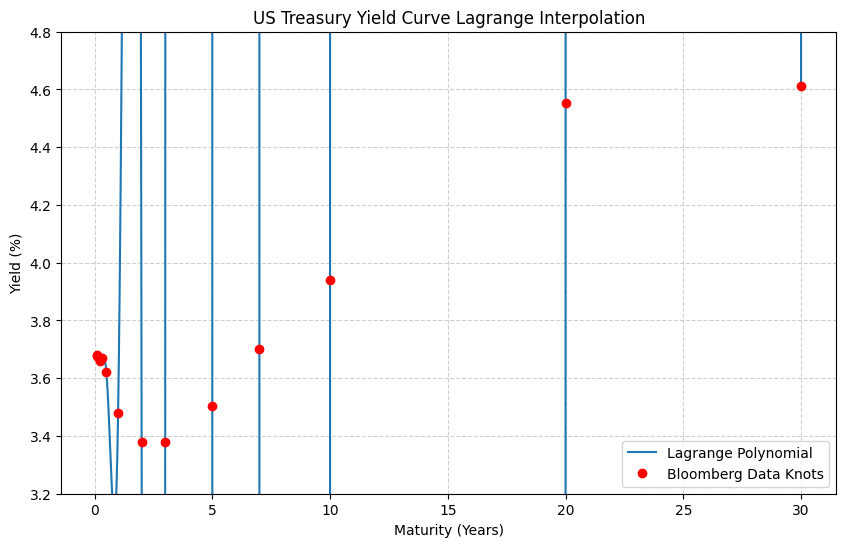

In [19]:
def plot_manual_polynomial(poly_func, x_nodes, y_nodes):
    """
    Takes a polynomial function and the original nodes, and graphs them
    using the exact scaling and styling of the spline graph.
    """
    # 1. Update: Generate 5000 evenly spaced 'x' points to match the spline density
    dense_x = np.linspace(min(x_nodes), max(x_nodes), 5000)
    
    # Evaluate our manually created function at all 5000 points
    dense_y = poly_func(dense_x)
    
    # 2. Update: Maintain the exact 10x6 figure size
    plt.figure(figsize=(10, 6))
    
    # Plot the continuous Lagrange polynomial first (matches the line plot style)
    plt.plot(dense_x, dense_y, label="Lagrange Polynomial")
    
    # 3. Update: Plot the original market data points using 'ro' and markersize=6
    plt.plot(x_nodes, y_nodes, 'ro', label="Bloomberg Data Knots", markersize=6)
    
    # 4. Update: Match all specific titles and axis labels
    plt.title("US Treasury Yield Curve Lagrange Interpolation")
    plt.xlabel("Maturity (Years)")
    plt.ylabel("Yield (%)")
    
    plt.ylim(3.2, 4.8)

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.show()

plot_manual_polynomial(P_x, x, y)

# <center>Implied Volatility Newton Iteration</center>

Remark:
The formula of a Call Option derived from the Black-Scholes Model is:
$$C(S, K, T, r, q, \sigma) = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)$$
where
$$d_1 = \frac{\ln(S/K) + (r - q + \sigma^2/2)T}{\sigma \sqrt{T}}$$
$$d_2 = d_1 - \sigma \sqrt{T}$$

So now, what we are trying to do is that we reverse engineer the Black-Scholes Model to find the implied volatility ($\sigma$) that matches the market price of the option (C), the strike price (K), the time to maturity (T), the risk-free rate (r), and the dividend yield (q).

For now, lets assume that the dividend yield (q) is the annual dividend yield (Which actually might be innacurate for shorter term options).

Remark: Newton's Method
$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

* $x_n$: Your current guess.
* $f(x_n)$: The current error (value of the function).
* $f'(x_n)$: The derivative (slope) at that point.

Pattern recognition:
$$\sigma_{new} = \sigma_{old} - \frac{BS(\sigma_{old}) - P_{market}}{\text{Vega}(\sigma_{old})}$$

Where:
* $BS(\sigma_{old})$ is the theoretical price.
* $P_{market}$ is the observed market price.
* $\text{Vega}$ is the derivative of price with respect to volatility ($\frac{\partial C}{\partial \sigma}$).

And the formula of Vega is:
$$\text{Vega} = \frac{\partial C}{\partial \sigma} = S \sqrt{T} \cdot \phi(d_1)$$
Where:

$\phi(x)$ is the standard normal probability density function (PDF): $\phi(x) = \frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2}x^2}$.



Why can we do this? 
Remember the 3 condition for newton method:
1. $f \in C^2$
2. $f'(x*) \neq 0$
3. $x_0$ is close enough to $x*$

First we collect the data from the excel first

In [10]:
# An Alternate fetching system from yfinance But lets not use this
# --- 1. FETCH DATA INTO DATAFRAME ---
def get_option_chain_df(ticker_symbol, expiration_date):
    """
    Fetches the entire Call Option Chain as a Pandas DataFrame.
    """
    ticker = yf.Ticker(ticker_symbol)
    
    # Get the current stock price (Spot)
    # fast_info is efficient; it avoids downloading full history
    S = ticker.fast_info['last_price']
    
    # Download the chain
    try:
        opt_chain = ticker.option_chain(expiration_date)
        calls_df = opt_chain.calls
    except ValueError:
        print(f"Error: Expiration {expiration_date} not found.")
        return None

    # The option_chain dataframe natively returns 'bid' and 'ask' columns 
    # for every single contract. We just need to average them.
    calls_df['mid_price'] = (calls_df['bid'] + calls_df['ask']) / 2

    # Add the Spot Price (S) and Time to Maturity (T) to every row
    calls_df['spot_price'] = S
    
    # Calculate T (Time to Maturity in Years)
    today = datetime.now()
    exp_date = datetime.strptime(expiration_date, "%Y-%m-%d")
    T = (exp_date - today).days / 365.0
    calls_df['time_to_exp'] = T
    
    return calls_df

In [11]:
import pandas as pd
from datetime import datetime

def fetch_SP_data_from_excel(file_path, expiration_date, snapshot_date="2026-02-27"):
    """
    Fetches S&P Call Option Chain from an Excel file.
    
    Inputs: 
    - expiration_date: Must be in standard 'YYYY-MM-DD' format (e.g., '2031-12-19')
    - snapshot_date: Must be in standard 'YYYY-MM-DD' format.
    """
    
    # 1. Open the Excel file strictly to read the tab names
    try:
        xls = pd.ExcelFile(file_path)
    except Exception as e:
        print(f"Error opening file: {e}")
        return None

    # 2. Find the exact tab name
    # Since your tabs are exactly 'YYYY-MM-DD', we just check if it exists directly!
    if expiration_date in xls.sheet_names:
        actual_sheet_name = expiration_date
    else:
        print(f"Error: Could not find an Excel tab for '{expiration_date}'.")
        return None

    # 3. Read the specific, matched tab
    df = pd.read_excel(xls, sheet_name=actual_sheet_name, header=None)
    
    # 4. Assign column names based on the side-by-side structure
    cols = ['strike', 'ticker', 'bid', 'ask', 'last', 'ivm',
            'put_strike', 'put_ticker', 'put_bid', 'put_ask', 'put_last', 'put_ivm']

    df.columns = cols[:len(df.columns)] 
    
    # Keep only the Call columns
    calls_df = df[['ticker', 'strike', 'bid', 'ask', 'last', 'ivm']].copy()
    
    # 5. Clean the data: filter out string header rows
    calls_df['strike'] = pd.to_numeric(calls_df['strike'], errors='coerce')
    calls_df = calls_df.dropna(subset=['strike']).copy()
    
    for col in ['bid', 'ask', 'last', 'ivm']:
        calls_df[col] = pd.to_numeric(calls_df[col], errors='coerce').fillna(0)
    
    # 6. Calculate Mid Price
    calls_df['mid_price'] = (calls_df['bid'] + calls_df['ask']) / 2
    
    # 7. Calculate Time to Maturity (T)
    target_date_obj = datetime.strptime(expiration_date, "%Y-%m-%d")
    snapshot_date_obj = datetime.strptime(snapshot_date, "%Y-%m-%d")
    
    T = (target_date_obj - snapshot_date_obj).days / 365.0
    
    # Safety catch for 0-DTE options
    if T <= 0:
        T = 1e-5 

    calls_df['time_to_exp'] = T

    # 8. Adjust IVM to decimals
    calls_df['ivm'] = calls_df['ivm'] / 100
    
    return calls_df.reset_index(drop=True)

# --- How to run it now ---
calls_long_term = fetch_SP_data_from_excel("SPX OMON New.xlsx", "2031-12-19")
calls_short_term = fetch_SP_data_from_excel("SPX OMON New.xlsx", "2026-03-27")
calls_short_term

,ticker,strike,bid,ask,last,ivm,mid_price,time_to_exp
0,SPXW 3/27/26 C2200,2200.0,4667.898438,4684.601562,0.0,0.000000,4676.250000,0.076712
1,SPXW 3/27/26 C2400,2400.0,4468.500000,4485.398438,0.0,0.000000,4476.949219,0.076712
2,SPXW 3/27/26 C2600,2600.0,4269.199219,4289.300781,0.0,0.000000,4279.250000,0.076712
3,SPXW 3/27/26 C2800,2800.0,4069.800049,4090.000000,0.0,0.000000,4079.900024,0.076712
4,SPXW 3/27/26 C3000,3000.0,3870.399902,3890.600098,0.0,0.000000,3880.500000,0.076712
...,...,...,...,...,...,...,...,...
204,SPXW 3/27/26 C8200,8200.0,0.000000,0.150000,0.0,0.203721,0.075000,0.076712
205,SPXW 3/27/26 C8400,8400.0,0.000000,0.150000,0.0,0.229227,0.075000,0.076712
206,SPXW 3/27/26 C8600,8600.0,0.000000,0.150000,0.0,0.253858,0.075000,0.076712
207,SPXW 3/27/26 C8800,8800.0,0.000000,0.150000,0.0,0.277748,0.075000,0.076712


In [12]:
def get_risk_free_rate(time_to_exp, x_nodes, y_nodes, a, b, c, d):
    return get_y(time_to_exp, x_nodes, y_nodes, a, b, c, d)

def black_scholes_call_div(S, K, T, r, q, sigma):
    """Black-Scholes Call Price with Continuous Dividend Yield (q)"""
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    term1 = S * np.exp(-q * T) * norm.cdf(d1)
    term2 = K * np.exp(-r * T) * norm.cdf(d2)
    return term1 - term2

def calculate_vega_div(S, K, T, r, q, sigma):
    """Vega with Continuous Dividend Yield (q)"""
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)

def get_dividend_yield(ticker_symbol):
    ticker = yf.Ticker(ticker_symbol)
    
    # yfinance returns a dictionary of info
    # 'dividendYield' is usually a decimal (e.g., 0.0075 for 0.75%)
    div_yield = ticker.info.get('dividendYield')
    
    # Safety check: If the company doesn't pay dividends, it might return None
    if div_yield is None:
        return 0.0
        
    return div_yield

def get_opening_price(ticker_symbol, date_str):
    """
    Retrieves the opening price for a given ticker on a specific date.
    date_str must be in 'YYYY-MM-DD' format.
    """
    try:
        # Convert string to a datetime object
        target_date = datetime.strptime(date_str, '%Y-%m-%d')
        
        # yfinance needs an 'end' date to pull a range. We'll set it to the very next day.
        next_day = target_date + timedelta(days=1)
        
        # Fetch the data
        stock_data = yf.download(
            tickers=ticker_symbol, 
            start=target_date.strftime('%Y-%m-%d'), 
            end=next_day.strftime('%Y-%m-%d'),
            progress=False # Hides the loading bar for cleaner output
        )
        
        # Check if the dataframe is empty (usually means a weekend or holiday)
        if stock_data.empty:
            return f"No data found for {ticker_symbol} on {date_str}. The market was likely closed."
        
        # Extract the opening price (converting to float for a clean number)
        # Note: If yfinance returns a MultiIndex, we handle it by pulling the raw value.
        open_price = float(stock_data['Open'].iloc[0])
        
        return round(open_price, 2)
        
    except Exception as e:
        return f"An error occurred: {e}"

# Example Usage for SPX
DIVIDEND_YIELD = 0.0122
SPOT_PRICE = 6856.54

In [13]:
import numpy as np
from scipy.stats import norm

def calculate_iv_newton(df, tol=1e-6, max_iter=100):
    """
    Calculates Implied Volatility using a vectorized Newton Method.
    Stops dynamically when all options converge, and tracks iterations per row.
    """
    # A. Extract Full Arrays
    market_price = df['mid_price'].values
    K = df['strike'].values
    T = df['time_to_exp'].values

    # Global Scalars 
    S = SPOT_PRICE
    q = DIVIDEND_YIELD
    r = get_risk_free_rate(T[0], x, y, a, b, c, d)/100
    
    # B. Initialization
    sigma = np.full(len(df), 0.5)
    final_vega = np.zeros(len(df))
    iterations = np.zeros(len(df), dtype=int) # <--- New iteration tracker

    # C. The Dynamic Newton Loop
    for i in range(max_iter):
        
        # 1. Black-Scholes Math 
        d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        
        model_price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        vega = S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T) 
        
        # 2. Calculate Error
        diff = market_price - model_price
        
        # 3. Check Convergence
        needs_update = np.abs(diff) > tol
        
        if not np.any(needs_update):
            break
            
        # 4. Increment the iteration counter ONLY for rows still updating
        iterations[needs_update] += 1 
        
        # 5. Calculate the Newton Step 
        step = diff / (vega + 1e-15)
        
        # 6. Apply the step
        sigma[needs_update] += step[needs_update]
        sigma = np.maximum(sigma, 0.001)
        
        # Store the vega 
        final_vega = vega

    print(f"Solver finished after {i + 1} maximum loop cycles.")
    
    # Return all three arrays
    return sigma, final_vega, iterations

We insert our calculated IVs into the dataframe and some other statistics to help us visualize the process.

In [14]:

calls_long_term['calculated_iv'], calls_long_term['vega'], calls_long_term['iterations'] = calculate_iv_newton(
    calls_long_term
)
calls_long_term['relative_error'] = np.abs(
    (calls_long_term['calculated_iv'] - calls_long_term['ivm']) / calls_long_term['ivm']
)
calls_long_term['risk_free_rate'] = get_risk_free_rate(calls_long_term['time_to_exp'].iloc[0], x, y, a, b, c, d)/100

calls_long_term['model_price'] = black_scholes_call_div(
    SPOT_PRICE, 
    calls_long_term['strike'], 
    calls_long_term['time_to_exp'], 
    calls_long_term['risk_free_rate'], 
    DIVIDEND_YIELD, 
    calls_long_term['calculated_iv']
)

cols_to_show = [
    'strike', 'mid_price', 'model_price', 'ivm','calculated_iv', 'vega', 'iterations', 'relative_error', 'risk_free_rate'
]

print(calls_long_term[cols_to_show].to_string())

Solver finished after 7 maximum loop cycles.
     strike    mid_price  model_price       ivm  calculated_iv         vega  iterations  relative_error  risk_free_rate
0    2000.0  5009.398438  5009.398438  0.000000       0.519091  1399.574895           3             inf        0.035814
1    2400.0  4740.796875  4740.796875  0.000000       0.486759  1712.620212           3             inf        0.035814
2    2800.0  4417.500000  4417.500000  0.000000       0.429817  1950.015222           3             inf        0.035814
3    3200.0  4128.500000  4128.500000  0.000000       0.397423  2248.640006           3             inf        0.035814
4    3600.0  3846.399902  3846.399903  0.138917       0.370801  2566.208517           3        1.669221        0.035814
5    4000.0  3571.199951  3571.199951  0.190539       0.348277  2900.206758           3        0.827848        0.035814
6    4400.0  3304.699951  3304.699951  0.202593       0.329276  3249.028247           3        0.625311        0.03

Add some information to the df as well

In [15]:
calls_short_term['calculated_iv'], calls_short_term['vega'], calls_short_term['iterations'] = calculate_iv_newton(
    calls_short_term
)
calls_short_term['relative_error'] = np.abs(
    (calls_short_term['calculated_iv'] - calls_short_term['ivm']) / calls_short_term['ivm']
)
calls_short_term['risk_free_rate'] = get_risk_free_rate(calls_short_term['time_to_exp'].iloc[0], x, y, a, b, c, d)/100

calls_short_term['model_price'] = black_scholes_call_div(
    SPOT_PRICE, 
    calls_short_term['strike'], 
    calls_short_term['time_to_exp'], 
    calls_short_term['risk_free_rate'], 
    DIVIDEND_YIELD, 
    calls_short_term['calculated_iv']
)

cols_to_show = [
    'strike', 'mid_price', 'model_price', 'ivm','calculated_iv', 'vega', 'iterations', 'relative_error', 'risk_free_rate'
]

print(calls_short_term[cols_to_show].to_string())

Solver finished after 100 maximum loop cycles.
     strike    mid_price  model_price       ivm  calculated_iv        vega  iterations  relative_error  risk_free_rate
0    2200.0  4676.250000  4656.321172  0.000000       0.001000    0.000000         100             inf         0.03676
1    2400.0  4476.949219  4456.884367  0.000000       0.001000    0.000000         100             inf         0.03676
2    2600.0  4279.250000  4257.447561  0.000000       0.001000    0.000000         100             inf         0.03676
3    2800.0  4079.900024  4058.010756  0.000000       0.001000    0.000000         100             inf         0.03676
4    3000.0  3880.500000  3858.573950  0.000000       0.001000    0.000000         100             inf         0.03676
5    3200.0  3679.700073  3659.137145  0.000000       0.001000    0.000000         100             inf         0.03676
6    3400.0  3480.650024  3459.700340  0.000000       0.001000    0.000000         100             inf         0.03676
7

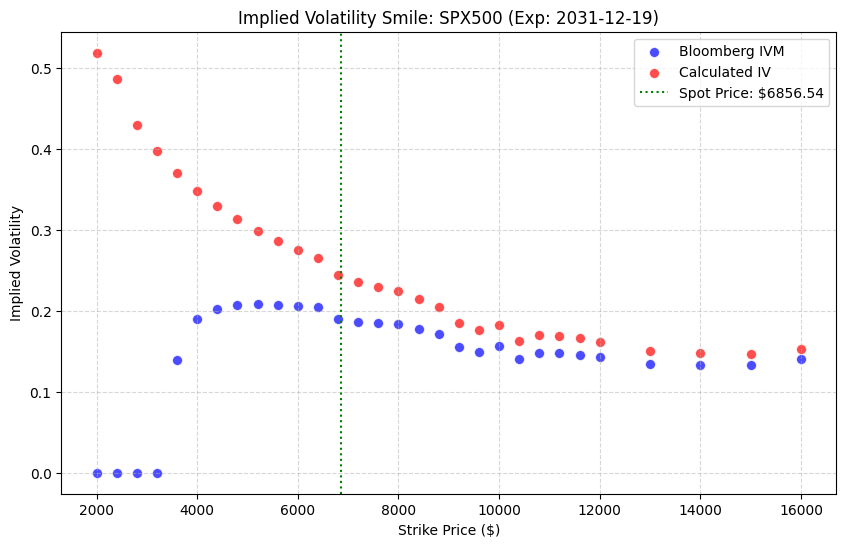

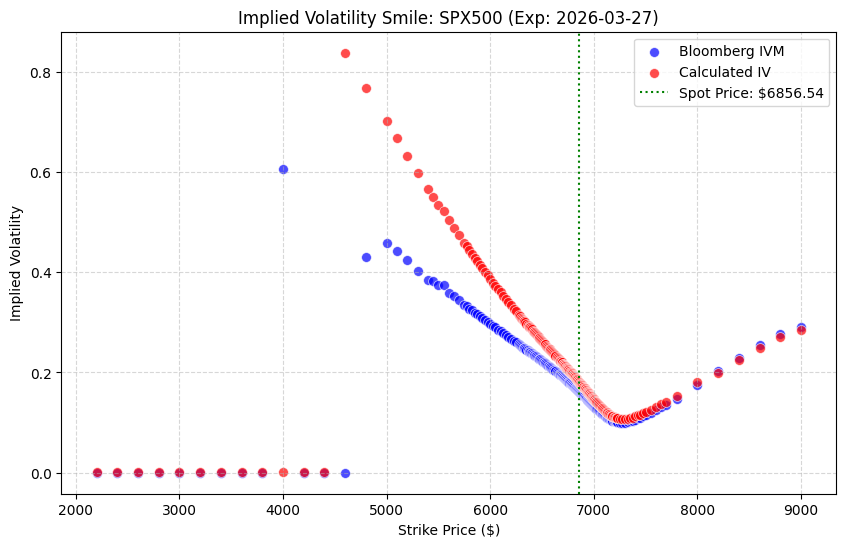

In [16]:
def plot_2d_smile(df, ticker="TICKER", date="EXPIRATION"):
    """
    Plots a 2D Implied Volatility Smile (Strike vs IV).
    """
    plt.figure(figsize=(10, 6))
    
    # 1. Plot the Market IV (The "Smile")
    # We use a scatter plot because option data is discrete points
    sns.scatterplot(
        data=df, 
        x='strike', 
        y='ivm', 
        label='Bloomberg IVM', 
        color='blue', 
        s=50,       # Marker size
        alpha=0.7   # Transparency
    )

    # 2. (Optional) Plot your Calculated IV if it exists
    if 'calculated_iv' in df.columns:
        sns.scatterplot(
            data=df,
            x='strike',
            y='calculated_iv',
            label='Calculated IV',
            color='red',
            s=50,
            alpha=0.7
        )

    # # 3. Add Spot Price Reference (The "Money" Line)
 
    plt.axvline(x=SPOT_PRICE, color='green', linestyle=':', label=f'Spot Price: ${SPOT_PRICE:.2f}')

    # 4. Styling & Labels
    plt.title(f'Implied Volatility Smile: {ticker} (Exp: {date})')
    plt.xlabel('Strike Price ($)')
    plt.ylabel('Implied Volatility')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    
    # Optional: Zoom in on the interesting part (ATM +/- 50%)
    # plt.xlim(spot * 0.5, spot * 1.5)

    plt.show()

plot_2d_smile(calls_long_term, ticker="SPX500", date="2031-12-19")
plot_2d_smile(calls_short_term, ticker="SPX500", date="2026-03-27")